# EPMT Data "Cleanup"

Taking 40k rows of EPMT data pulled from the database and written to file on Feb 7th, 2026, and cleaning that up so that it can be more easily used for Machine Learning. Revised version will be written to file as csv, hopefully with data normalization and outliers removed.


In [1]:
%pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
import ast

%matplotlib inline 

# Suggested by Gemini -- "Makes your plots look a bit more modern/clean"
sns.set_theme(style="whitegrid")

# Load some data

In [3]:
import glob
import os

data_path = './data_40000_20260207_083037' 

all_files = glob.glob(os.path.join(data_path, "*.csv"))

df_list = [pd.read_csv(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True)
print(f"Loaded {len(all_files)} files.")
pprint.pprint(all_files)


Loaded 8 files.
['./data_40000_20260207_083037/jk_data_40000_4_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_5_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_6_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_7_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_1_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_3_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_2_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_8_20260207_083037.csv']


In [4]:
df.columns.tolist()

['read_bytes',
 'write_bytes',
 'time_waiting',
 'cpu_time',
 'duration',
 'start',
 'end',
 'minflt',
 'majflt',
 'tags',
 'annotations',
 'all_proc_tags',
 'exitcode',
 'SLURM_JOB_ACCOUNT',
 'SLURM_NTASKS',
 'SLURM_TASKS_PER_NODE',
 'SLURM_MEM_PER_CPU',
 'SLURM_MEM_PER_NODE',
 'SLURM_SCRIPT_CONTEXT',
 'LOADEDMODULES']

In [5]:
len(df)

40000

# Parse the annotations

In a rush, the data was just written to file, and now we have to parse it. It's basically the EPMT_JOB_TAGS, with some papiex-related tags.

In [6]:
#Just look at one of them for now
type(df.iloc[0]['annotations'])
annotations = ast.literal_eval(df.iloc[0]['annotations'])
epmt_job_tags_str = annotations['EPMT_JOB_TAGS']
epmt_job_tags_str

'exp_component:ocean_rho2;exp_fre_mod:/home/fms/local/opt/fre-commands/bronx-23;exp_name:SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X;exp_time:00390101;exp_platform:gfdl.ncrc5-intel23_2_0;exp_target:repro-openmp;exp_seg_months:12;script_name:SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X_ocean_rho2_00390101'

In [7]:
# Turn all of the annotations from strings to dictionaries to process easier
expanded_annotations = pd.json_normalize(df["annotations"].apply(ast.literal_eval))
expanded_annotations

,EPMT_JOB_TAGS,papiex-error,papiex-error-process-ids
0,exp_component:ocean_rho2;exp_fre_mod:/home/fms...,NaN,NaN
1,exp_component:ocean_z;exp_fre_mod:/home/fms/lo...,NaN,NaN
2,exp_component:ocean;exp_fre_mod:/home/fms/loca...,NaN,NaN
3,exp_component:ocean_scalar;exp_fre_mod:/home/f...,NaN,NaN
4,exp_component:ice;exp_fre_mod:/home/fms/local/...,NaN,NaN
...,...,...,...
39995,exp_component:ocean_monthly_z;exp_fre_mod:/hom...,NaN,NaN
39996,exp_component:ocean_monthly_rho0;exp_fre_mod:/...,NaN,NaN
39997,exp_component:ocean_monthly_rho2;exp_fre_mod:/...,NaN,NaN
39998,exp_component:ocean_annual_z;exp_fre_mod:/home...,NaN,NaN


In [8]:
# Now, expand the EPMT_JOB_TAGS strings into dictionaries
def parse_key_val_str(kv_str: str):
    if not isinstance(kv_str, str) or not kv_str:
        return {}
    return dict(item.split(":") for item in kv_str.split(";"))

expanded_annotations["parsed_EPMT_JOB_TAGS"] = expanded_annotations["EPMT_JOB_TAGS"].apply(parse_key_val_str)

In [9]:
# Turn the dictionaries into columns with values using pd.Series
# Join the parsed EPMT tags to the expanded annotations
parsed_epmt_data = expanded_annotations.join(expanded_annotations["parsed_EPMT_JOB_TAGS"].apply(pd.Series)) 

In [10]:
# Finally, join the tags to the original dataframe
df = df.join(parsed_epmt_data)
df.drop(columns=['parsed_EPMT_JOB_TAGS'])

,read_bytes,write_bytes,time_waiting,cpu_time,duration,start,end,minflt,majflt,tags,...,papiex-error,papiex-error-process-ids,exp_component,exp_fre_mod,exp_name,exp_time,exp_platform,exp_target,exp_seg_months,script_name
0,143108292608,87625113600,1576818392,2.447686e+08,1.351581e+09,2026-01-28 09:15:39.211909,2026-01-28 09:38:10.792654,16121206,89,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,NaN,ocean_rho2,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
1,530551828480,320059248640,1609037432,8.158229e+08,2.690247e+09,2026-01-28 09:15:39.224952,2026-01-28 10:00:29.471986,67307150,95,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,NaN,ocean_z,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
2,20732755968,15446900736,1287584605,7.107885e+07,1.103452e+09,2026-01-28 09:15:39.234004,2026-01-28 09:34:02.685979,5572074,1,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,NaN,ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
3,2519040,9170944,1060678240,1.574165e+07,7.748793e+08,2026-01-28 09:15:39.267702,2026-01-28 09:28:34.147049,1831911,9,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,NaN,ocean_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
4,51357884416,39814533120,2412909975,2.985102e+08,1.657239e+09,2026-01-28 09:15:39.495806,2026-01-28 09:43:16.734767,10174529,0,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,NaN,ice,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,949433233408,1093601648640,8003719425,2.194842e+09,3.618123e+09,2026-02-04 14:22:53.830723,2026-02-04 15:23:11.953871,187455457,814,"{'exp_name': 'abrupt-4xCO2_fire_chem_climo', '...",...,NaN,NaN,ocean_monthly_z,/home/fms/local/opt/fre-commands/test,abrupt-4xCO2_fire_chem_climo,00850101,gfdl.ncrc5-intel25,prod-openmp,12,abrupt-4xCO2_fire_chem_climo_ocean_monthly_z_0...
39996,12288,3895296,618124336,3.584483e+06,4.279246e+07,2026-02-04 14:22:56.814316,2026-02-04 14:23:39.606775,453152,0,"{'exp_name': 'abrupt-4xCO2_fire_chem_climo', '...",...,NaN,NaN,ocean_monthly_rho0,/home/fms/local/opt/fre-commands/test,abrupt-4xCO2_fire_chem_climo,00850101,gfdl.ncrc5-intel25,prod-openmp,12,abrupt-4xCO2_fire_chem_climo_ocean_monthly_rho...
39997,106496,4939776,1506755561,6.771812e+06,5.475408e+07,2026-02-04 14:22:59.839467,2026-02-04 14:23:54.593549,865908,5,"{'exp_name': 'abrupt-4xCO2_fire_chem_climo', '...",...,NaN,NaN,ocean_monthly_rho2,/home/fms/local/opt/fre-commands/test,abrupt-4xCO2_fire_chem_climo,00850101,gfdl.ncrc5-intel25,prod-openmp,12,abrupt-4xCO2_fire_chem_climo_ocean_monthly_rho...
39998,232376201216,379891113984,6402154311,9.620012e+08,1.618102e+09,2026-02-04 14:23:04.040949,2026-02-04 14:50:02.142913,126774627,1437,"{'exp_name': 'abrupt-4xCO2_fire_chem_climo', '...",...,NaN,NaN,ocean_annual_z,/home/fms/local/opt/fre-commands/test,abrupt-4xCO2_fire_chem_climo,00850101,gfdl.ncrc5-intel25,prod-openmp,12,abrupt-4xCO2_fire_chem_climo_ocean_annual_z_00...


## Parse 'all_proc_tags'

In [11]:
#Just look at one of them for now
df.iloc[0]['all_proc_tags']

"[{'op': 'cp', 'op_instance': '1'}, {'op': 'dmput', 'op_instance': '2'}, {'op': 'dmput', 'op_instance': '3'}, {'op': 'hsmget', 'op_instance': '1'}, {'op': 'hsmget', 'op_instance': '4'}, {'op': 'mv', 'op_instance': '1'}, {'op': 'mv', 'op_instance': '3'}, {'op': 'mv', 'op_instance': '4'}, {'op': 'mv', 'op_instance': '6'}, {'op': 'ncatted', 'op_instance': '2'}, {'op': 'ncatted', 'op_instance': '3'}, {'op': 'ncks', 'op_instance': '2'}, {'op': 'ncrcat', 'op_instance': '1'}, {'op': 'ncrcat', 'op_instance': '2'}, {'op': 'rm', 'op_instance': '1'}, {'op': 'rm', 'op_instance': '2'}, {'op': 'rm', 'op_instance': '4'}, {'op': 'rm', 'op_instance': '5'}, {'op': 'splitvars', 'op_instance': '2'}, {'op': 'timavg', 'op_instance': '1'}]"

In [12]:
pprint.pprint(df.iloc[0]['all_proc_tags'])

("[{'op': 'cp', 'op_instance': '1'}, {'op': 'dmput', 'op_instance': '2'}, "
 "{'op': 'dmput', 'op_instance': '3'}, {'op': 'hsmget', 'op_instance': '1'}, "
 "{'op': 'hsmget', 'op_instance': '4'}, {'op': 'mv', 'op_instance': '1'}, "
 "{'op': 'mv', 'op_instance': '3'}, {'op': 'mv', 'op_instance': '4'}, {'op': "
 "'mv', 'op_instance': '6'}, {'op': 'ncatted', 'op_instance': '2'}, {'op': "
 "'ncatted', 'op_instance': '3'}, {'op': 'ncks', 'op_instance': '2'}, {'op': "
 "'ncrcat', 'op_instance': '1'}, {'op': 'ncrcat', 'op_instance': '2'}, {'op': "
 "'rm', 'op_instance': '1'}, {'op': 'rm', 'op_instance': '2'}, {'op': 'rm', "
 "'op_instance': '4'}, {'op': 'rm', 'op_instance': '5'}, {'op': 'splitvars', "
 "'op_instance': '2'}, {'op': 'timavg', 'op_instance': '1'}]")


In [13]:
type(df.iloc[0]['all_proc_tags'])

str

In [14]:
op_lists = df['all_proc_tags'].apply(ast.literal_eval)
op_lists

0        [{'op': 'cp', 'op_instance': '1'}, {'op': 'dmp...
1        [{'op': 'cp', 'op_instance': '1'}, {'op': 'dmp...
2        [{'op': 'cp', 'op_instance': '1'}, {'op': 'dmp...
3        [{'op': 'cp', 'op_instance': '1'}, {'op': 'dmp...
4        [{'op': 'cp', 'op_instance': '1'}, {'op': 'dmp...
                               ...                        
39995    [{'op': 'dmput', 'op_instance': '2'}, {'op': '...
39996    [{'op': 'hsmget', 'op_instance': '1'}, {'op': ...
39997    [{'op': 'dmput', 'op_instance': '2'}, {'op': '...
39998    [{'op': 'dmput', 'op_instance': '2'}, {'op': '...
39999    [{'op': 'dmput', 'op_instance': '2'}, {'op': '...
Name: all_proc_tags, Length: 40000, dtype: object

In [15]:
exploded_op_lists = op_lists.explode()
exploded_op_lists.head(30)

0           {'op': 'cp', 'op_instance': '1'}
0        {'op': 'dmput', 'op_instance': '2'}
0        {'op': 'dmput', 'op_instance': '3'}
0       {'op': 'hsmget', 'op_instance': '1'}
0       {'op': 'hsmget', 'op_instance': '4'}
0           {'op': 'mv', 'op_instance': '1'}
0           {'op': 'mv', 'op_instance': '3'}
0           {'op': 'mv', 'op_instance': '4'}
0           {'op': 'mv', 'op_instance': '6'}
0      {'op': 'ncatted', 'op_instance': '2'}
0      {'op': 'ncatted', 'op_instance': '3'}
0         {'op': 'ncks', 'op_instance': '2'}
0       {'op': 'ncrcat', 'op_instance': '1'}
0       {'op': 'ncrcat', 'op_instance': '2'}
0           {'op': 'rm', 'op_instance': '1'}
0           {'op': 'rm', 'op_instance': '2'}
0           {'op': 'rm', 'op_instance': '4'}
0           {'op': 'rm', 'op_instance': '5'}
0    {'op': 'splitvars', 'op_instance': '2'}
0       {'op': 'timavg', 'op_instance': '1'}
1           {'op': 'cp', 'op_instance': '1'}
1        {'op': 'dmput', 'op_instance': '2'}
1        {

In [16]:
exploded_op_series = exploded_op_lists.apply(pd.Series)

### Executive Decision --- I'm going to add up all of these instances for now
Argh... In the example I'm looking at, there are multiple timavg op_instance values per line. I'm not sure what to do, so for now, I'm going to try to sum up the values.

In [17]:
from collections import defaultdict

def sum_op_instances(all_proc_tags_str: str):
    sums = defaultdict(int)
    if not isinstance(all_proc_tags_str, str) or not all_proc_tags_str.strip(): # not a string or empty
        return sums
    op_instance_list = ast.literal_eval(all_proc_tags_str) # str to list of dicts
    for data in op_instance_list:
        op = data.get("op")
        op_instance = int(data.get("op_instance", 0))
        if op:
            sums[op] += op_instance
    return sums

op_instance_sums = df['all_proc_tags'].apply(sum_op_instances)
op_instance_sums

0        {'cp': 1, 'dmput': 5, 'hsmget': 5, 'mv': 14, '...
1        {'cp': 1, 'dmput': 5, 'hsmget': 5, 'mv': 14, '...
2        {'cp': 1, 'dmput': 9, 'hsmget': 5, 'mv': 29, '...
3        {'cp': 1, 'dmput': 5, 'hsmget': 24, 'mv': 14, ...
4        {'cp': 1, 'dmput': 9, 'hsmget': 5, 'mv': 29, '...
                               ...                        
39995    {'dmput': 5, 'hsmget': 21, 'mv': 13, 'ncatted'...
39996    {'hsmget': 5, 'mv': 1, 'ncatted': 1, 'ncks': 7...
39997    {'dmput': 2, 'hsmget': 5, 'mv': 3, 'ncatted': ...
39998    {'dmput': 2, 'hsmget': 21, 'mv': 89, 'ncatted'...
39999    {'dmput': 2, 'hsmget': 21, 'mv': 89, 'ncatted'...
Name: all_proc_tags, Length: 40000, dtype: object

In [18]:
# And, turn those into int columns, filling in any missing values
op_instance_sums = op_instance_sums.apply(pd.Series).fillna(0).astype(int)
op_instance_sums

,cp,dmput,hsmget,mv,ncatted,ncks,ncrcat,rm,splitvars,timavg,hsmput,fregrid,untar,plevel,dmget
0,1,5,5,14,5,2,3,12,2,1,0,0,0,0,0
1,1,5,5,14,5,2,3,12,2,1,0,0,0,0,0
2,1,9,5,29,8,92,9,34,2,4,0,0,0,0,0
3,1,5,24,14,5,2,3,12,2,1,0,0,0,0,0
4,1,9,5,29,8,92,9,34,2,4,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,0,5,21,13,4,78,5,17,2,1,0,0,0,0,0
39996,0,0,5,1,1,78,2,1,0,3,0,0,0,0,0
39997,0,2,5,3,1,78,2,6,0,3,0,0,0,0,0
39998,0,2,21,89,29,0,55,128,2,36,0,0,0,0,0


In [19]:
df = df.join(op_instance_sums)
df

,read_bytes,write_bytes,time_waiting,cpu_time,duration,start,end,minflt,majflt,tags,...,ncks,ncrcat,rm,splitvars,timavg,hsmput,fregrid,untar,plevel,dmget
0,143108292608,87625113600,1576818392,2.447686e+08,1.351581e+09,2026-01-28 09:15:39.211909,2026-01-28 09:38:10.792654,16121206,89,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,2,3,12,2,1,0,0,0,0,0
1,530551828480,320059248640,1609037432,8.158229e+08,2.690247e+09,2026-01-28 09:15:39.224952,2026-01-28 10:00:29.471986,67307150,95,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,2,3,12,2,1,0,0,0,0,0
2,20732755968,15446900736,1287584605,7.107885e+07,1.103452e+09,2026-01-28 09:15:39.234004,2026-01-28 09:34:02.685979,5572074,1,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,92,9,34,2,4,0,0,0,0,0
3,2519040,9170944,1060678240,1.574165e+07,7.748793e+08,2026-01-28 09:15:39.267702,2026-01-28 09:28:34.147049,1831911,9,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,2,3,12,2,1,0,0,0,0,0
4,51357884416,39814533120,2412909975,2.985102e+08,1.657239e+09,2026-01-28 09:15:39.495806,2026-01-28 09:43:16.734767,10174529,0,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,92,9,34,2,4,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,949433233408,1093601648640,8003719425,2.194842e+09,3.618123e+09,2026-02-04 14:22:53.830723,2026-02-04 15:23:11.953871,187455457,814,"{'exp_name': 'abrupt-4xCO2_fire_chem_climo', '...",...,78,5,17,2,1,0,0,0,0,0
39996,12288,3895296,618124336,3.584483e+06,4.279246e+07,2026-02-04 14:22:56.814316,2026-02-04 14:23:39.606775,453152,0,"{'exp_name': 'abrupt-4xCO2_fire_chem_climo', '...",...,78,2,1,0,3,0,0,0,0,0
39997,106496,4939776,1506755561,6.771812e+06,5.475408e+07,2026-02-04 14:22:59.839467,2026-02-04 14:23:54.593549,865908,5,"{'exp_name': 'abrupt-4xCO2_fire_chem_climo', '...",...,78,2,6,0,3,0,0,0,0,0
39998,232376201216,379891113984,6402154311,9.620012e+08,1.618102e+09,2026-02-04 14:23:04.040949,2026-02-04 14:50:02.142913,126774627,1437,"{'exp_name': 'abrupt-4xCO2_fire_chem_climo', '...",...,0,55,128,2,36,0,0,0,0,0


In [20]:
df.columns.tolist()

['read_bytes',
 'write_bytes',
 'time_waiting',
 'cpu_time',
 'duration',
 'start',
 'end',
 'minflt',
 'majflt',
 'tags',
 'annotations',
 'all_proc_tags',
 'exitcode',
 'SLURM_JOB_ACCOUNT',
 'SLURM_NTASKS',
 'SLURM_TASKS_PER_NODE',
 'SLURM_MEM_PER_CPU',
 'SLURM_MEM_PER_NODE',
 'SLURM_SCRIPT_CONTEXT',
 'LOADEDMODULES',
 'EPMT_JOB_TAGS',
 'papiex-error',
 'papiex-error-process-ids',
 'parsed_EPMT_JOB_TAGS',
 'exp_component',
 'exp_fre_mod',
 'exp_name',
 'exp_time',
 'exp_platform',
 'exp_target',
 'exp_seg_months',
 'script_name',
 'cp',
 'dmput',
 'hsmget',
 'mv',
 'ncatted',
 'ncks',
 'ncrcat',
 'rm',
 'splitvars',
 'timavg',
 'hsmput',
 'fregrid',
 'untar',
 'plevel',
 'dmget']

# Dropping some obviously useless columns
For example, the exitcodes all seem to have ended successfully, with value 0. That's not very useful, so let's remove them for now then. Same goes for some more columns.

In [21]:
df['exitcode'].value_counts().sort_index()

exitcode
0    40000
Name: count, dtype: int64

In [22]:
df = df.drop(columns=['exitcode'])

In [23]:
df['SLURM_MEM_PER_NODE'].value_counts().sort_index()

SLURM_MEM_PER_NODE
204800.0    5084
Name: count, dtype: int64

In [24]:
df = df.drop(columns=['SLURM_MEM_PER_NODE'])

In [25]:
df['SLURM_MEM_PER_CPU'].value_counts().sort_index()

SLURM_MEM_PER_CPU
16384.0    34113
Name: count, dtype: int64

In [26]:
df = df.drop(columns=['SLURM_MEM_PER_CPU'])

# Numerical Data  - Applying log, Skew/Outlier Detection + Clipping

It's time to do something with the numerical values to make them better for ML.

In [27]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
category_cols = df.select_dtypes(exclude="number").columns.tolist()

print("# numeric columns:", len(numeric_cols))
print("# category columns:", len(category_cols))

# numeric columns: 24
# category columns: 20


In [28]:
print("Numeric Columns", numeric_cols)
print("Category Columns", category_cols)

Numeric Columns ['read_bytes', 'write_bytes', 'time_waiting', 'cpu_time', 'duration', 'minflt', 'majflt', 'SLURM_NTASKS', 'SLURM_TASKS_PER_NODE', 'cp', 'dmput', 'hsmget', 'mv', 'ncatted', 'ncks', 'ncrcat', 'rm', 'splitvars', 'timavg', 'hsmput', 'fregrid', 'untar', 'plevel', 'dmget']
Category Columns ['start', 'end', 'tags', 'annotations', 'all_proc_tags', 'SLURM_JOB_ACCOUNT', 'SLURM_SCRIPT_CONTEXT', 'LOADEDMODULES', 'EPMT_JOB_TAGS', 'papiex-error', 'papiex-error-process-ids', 'parsed_EPMT_JOB_TAGS', 'exp_component', 'exp_fre_mod', 'exp_name', 'exp_time', 'exp_platform', 'exp_target', 'exp_seg_months', 'script_name']


### Detecting Skew
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.skew.html

We're shooting for skews between -1 and 1, where 0 is like a normal distribution.
Wow, our data is really skewed.

In [29]:
df.skew(numeric_only=True).sort_values(ascending=False)

ncatted                 190.383416
plevel                  173.005411
cp                      155.722903
untar                   155.446964
fregrid                 155.441631
rm                      150.852033
mv                      150.628441
ncrcat                   59.381124
timavg                   50.057457
SLURM_TASKS_PER_NODE     48.477407
SLURM_NTASKS             48.447670
majflt                   22.997401
time_waiting             16.604292
dmget                    13.807117
minflt                   10.508033
read_bytes                9.927572
duration                  9.221151
write_bytes               9.050809
ncks                      7.371235
cpu_time                  6.503564
hsmput                    4.905003
splitvars                 4.147187
hsmget                    3.666705
dmput                     3.319895
dtype: float64

In [30]:
# Try log transform - some are still skewed...
numerical_cols = df.select_dtypes(include="number").columns
df_log_trans = df.copy()
df_log_trans[numerical_cols] = np.log1p(df_log_trans[numerical_cols])
df_log_trans.skew(numeric_only=True).sort_values(ascending=False)

SLURM_TASKS_PER_NODE    48.477407
SLURM_NTASKS            48.447670
dmget                    7.972300
plevel                   7.591130
hsmput                   4.129237
timavg                   2.122476
fregrid                  1.484068
untar                    1.478296
ncrcat                   1.466381
ncks                     1.096532
cp                       0.930280
ncatted                  0.478010
minflt                   0.418819
majflt                   0.381172
cpu_time                 0.360376
rm                       0.211558
hsmget                   0.194736
mv                       0.184622
duration                 0.046672
time_waiting            -0.077002
dmput                   -0.106372
splitvars               -0.318547
write_bytes             -0.697371
read_bytes              -0.958198
dtype: float64

In [31]:
df.describe()

,read_bytes,write_bytes,time_waiting,cpu_time,duration,minflt,majflt,SLURM_NTASKS,SLURM_TASKS_PER_NODE,cp,...,ncks,ncrcat,rm,splitvars,timavg,hsmput,fregrid,untar,plevel,dmget
count,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,39950.000000,39999.000000,40000.000000,...,40000.000000,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000,40000.000000,40000.000000,40000.00000,40000.00000
mean,9.013787e+10,1.061092e+11,1.912810e+10,5.579547e+08,1.449861e+09,2.574613e+07,4.577521e+04,1.000426,1.000425,9.335775,...,23.959900,12.299325,75.505150,2.543525,11.46910,0.117675,2.628100,2.632225,0.91185,0.12925
std,4.145771e+11,3.500005e+11,1.527242e+11,1.592365e+09,4.651422e+09,1.043087e+08,7.364212e+05,0.020624,0.020612,91.337019,...,47.135149,73.677040,668.388059,2.517561,75.67673,0.499183,22.964588,22.964299,23.63041,1.15446
min,0.000000e+00,0.000000e+00,6.926000e+04,1.626600e+04,1.052534e+06,7.050000e+02,0.000000e+00,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000
25%,1.060045e+07,8.978790e+08,1.214052e+09,2.595877e+07,1.155357e+08,1.452388e+06,3.000000e+00,1.000000,1.000000,0.000000,...,0.000000,1.000000,3.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000
50%,4.187238e+08,5.431673e+09,3.600179e+09,7.294562e+07,3.489228e+08,4.647822e+06,6.300000e+01,1.000000,1.000000,0.000000,...,0.000000,1.000000,12.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000
75%,2.462538e+10,5.466200e+10,9.238051e+09,3.123325e+08,9.056736e+08,1.277289e+07,3.892500e+02,1.000000,1.000000,6.000000,...,20.000000,5.000000,82.000000,3.000000,1.00000,0.000000,2.000000,2.000000,0.00000,0.00000
max,7.814102e+12,6.462590e+12,5.649091e+12,3.527593e+10,1.677329e+11,2.141051e+09,3.404148e+07,2.000000,2.000000,16654.000000,...,2321.000000,8553.000000,120658.000000,36.000000,8100.00000,4.000000,4185.000000,4185.000000,4501.00000,46.00000


In [32]:
# I'm not sure what to do with SLURM_TASKS_PER_NODE and SLURM_NTASKS. They seem to be mainly around 1, but some maxing at 2. I'll remove them.

#df_log_trans = df_log_trans.drop(columns=['SLURM_NTASKS', 'SLURM_TASKS_PER_NODE'])
numeric_cols = df_log_trans.select_dtypes(include="number").columns
df_log_trans.skew(numeric_only=True).sort_values(ascending=False)

SLURM_TASKS_PER_NODE    48.477407
SLURM_NTASKS            48.447670
dmget                    7.972300
plevel                   7.591130
hsmput                   4.129237
timavg                   2.122476
fregrid                  1.484068
untar                    1.478296
ncrcat                   1.466381
ncks                     1.096532
cp                       0.930280
ncatted                  0.478010
minflt                   0.418819
majflt                   0.381172
cpu_time                 0.360376
rm                       0.211558
hsmget                   0.194736
mv                       0.184622
duration                 0.046672
time_waiting            -0.077002
dmput                   -0.106372
splitvars               -0.318547
write_bytes             -0.697371
read_bytes              -0.958198
dtype: float64

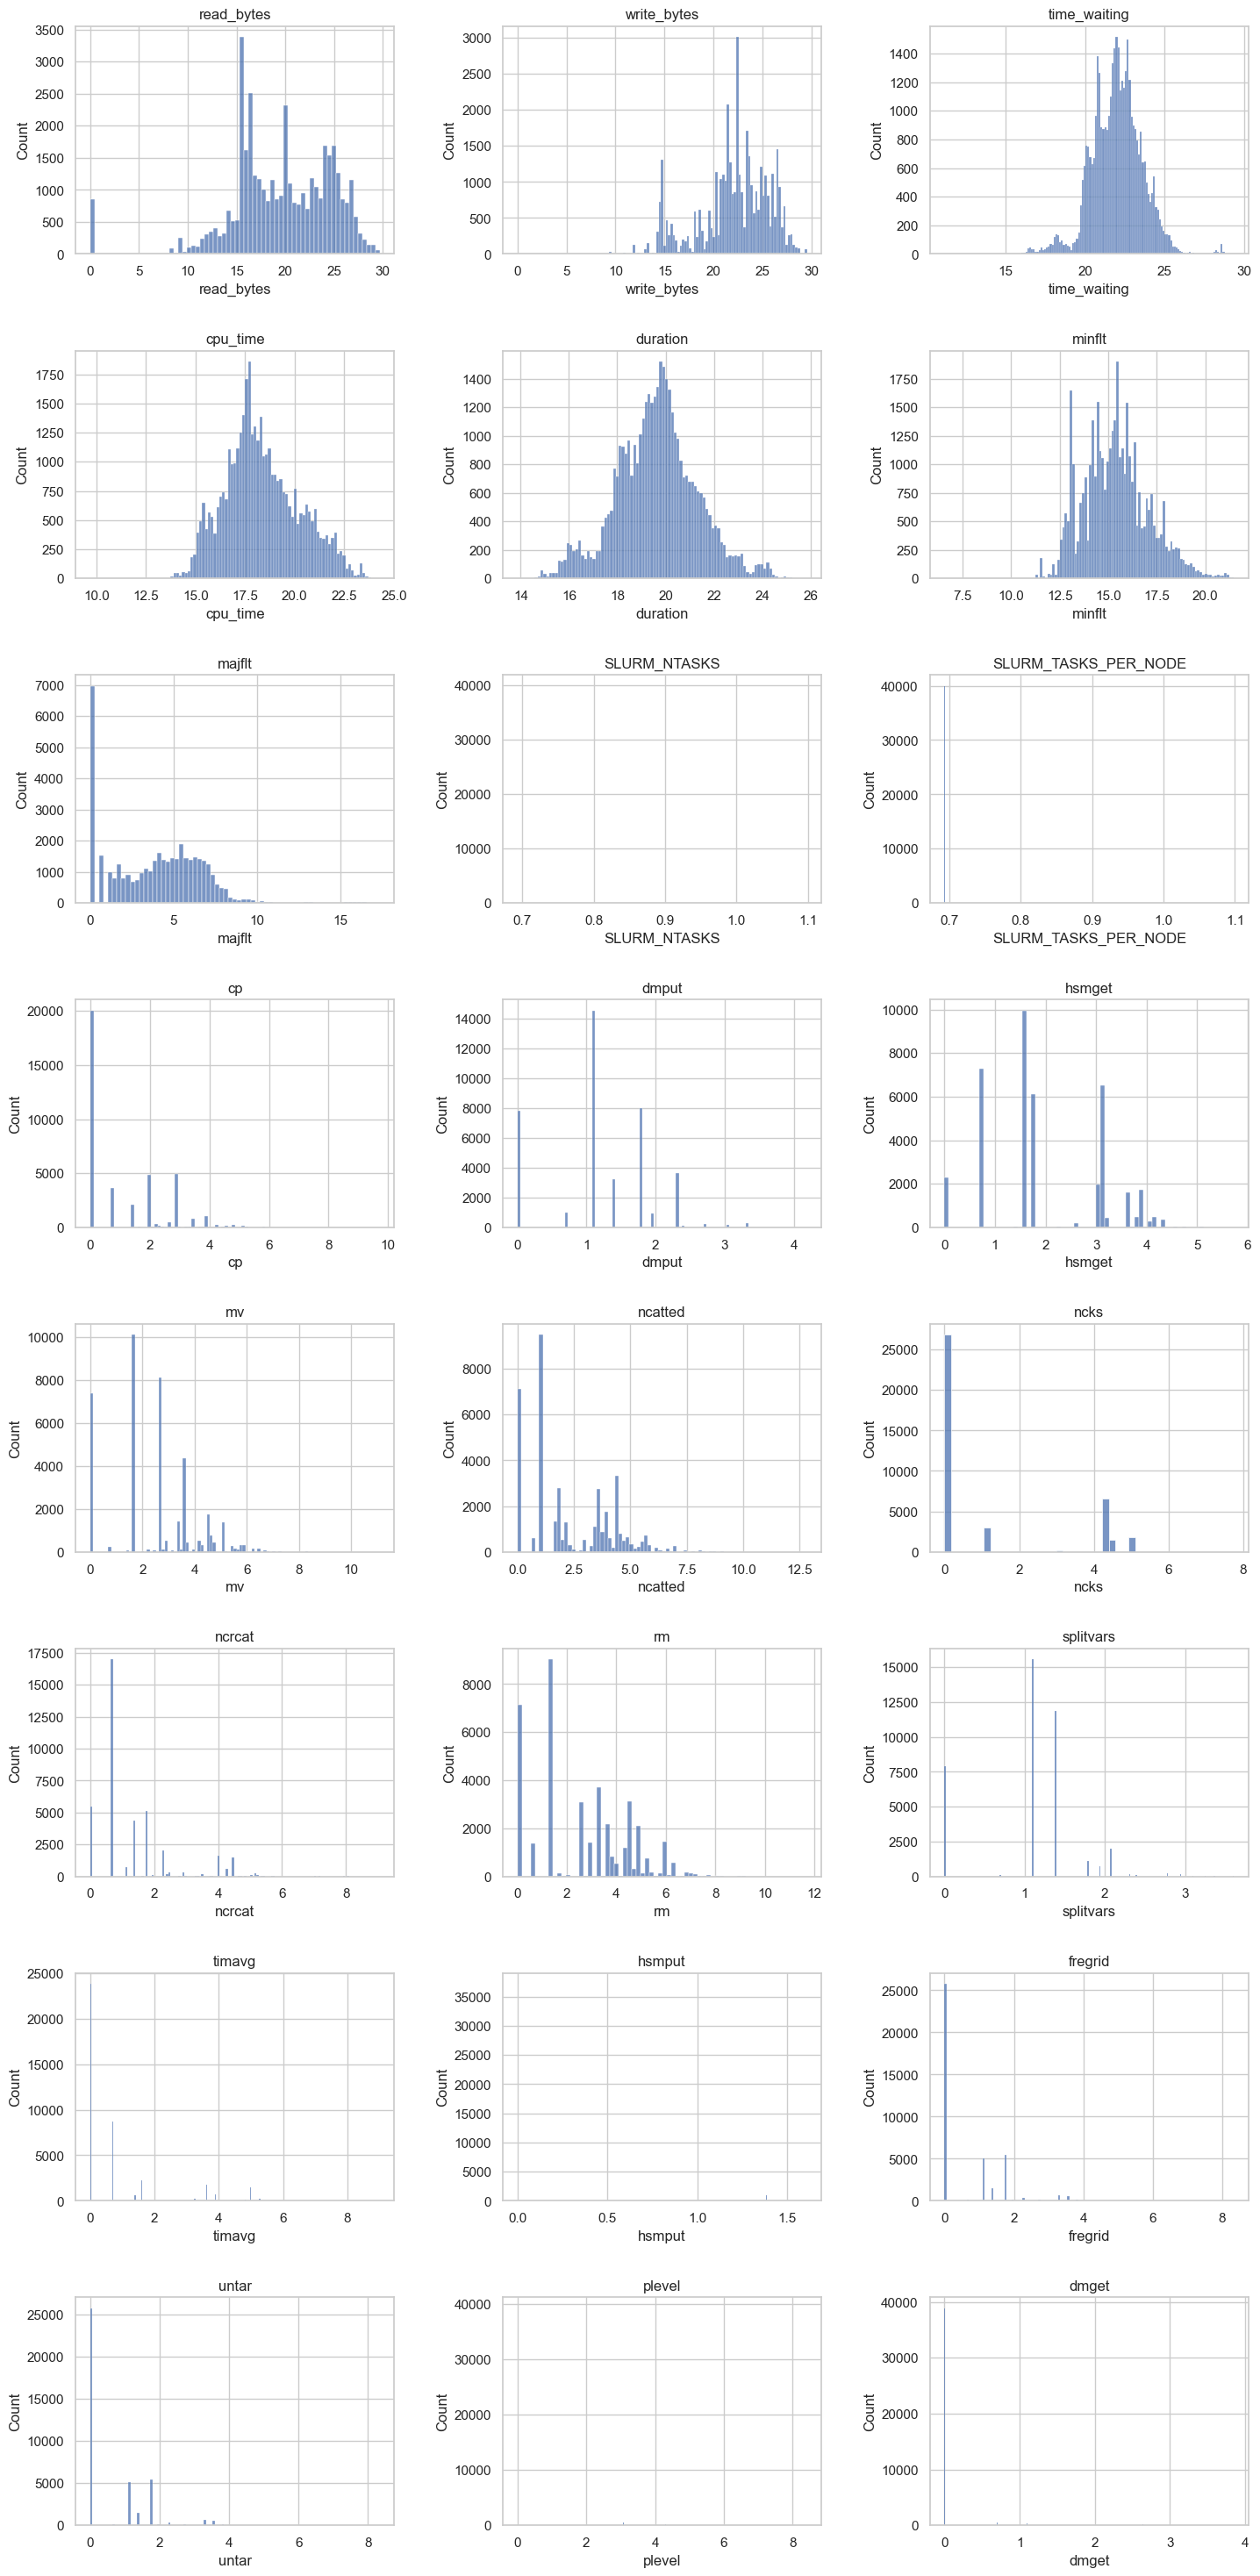

In [33]:
fig, axes = plt.subplots(8, 3, figsize=(15,30))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df_log_trans[col], ax=axes[i])
    #sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout(pad=2.5)

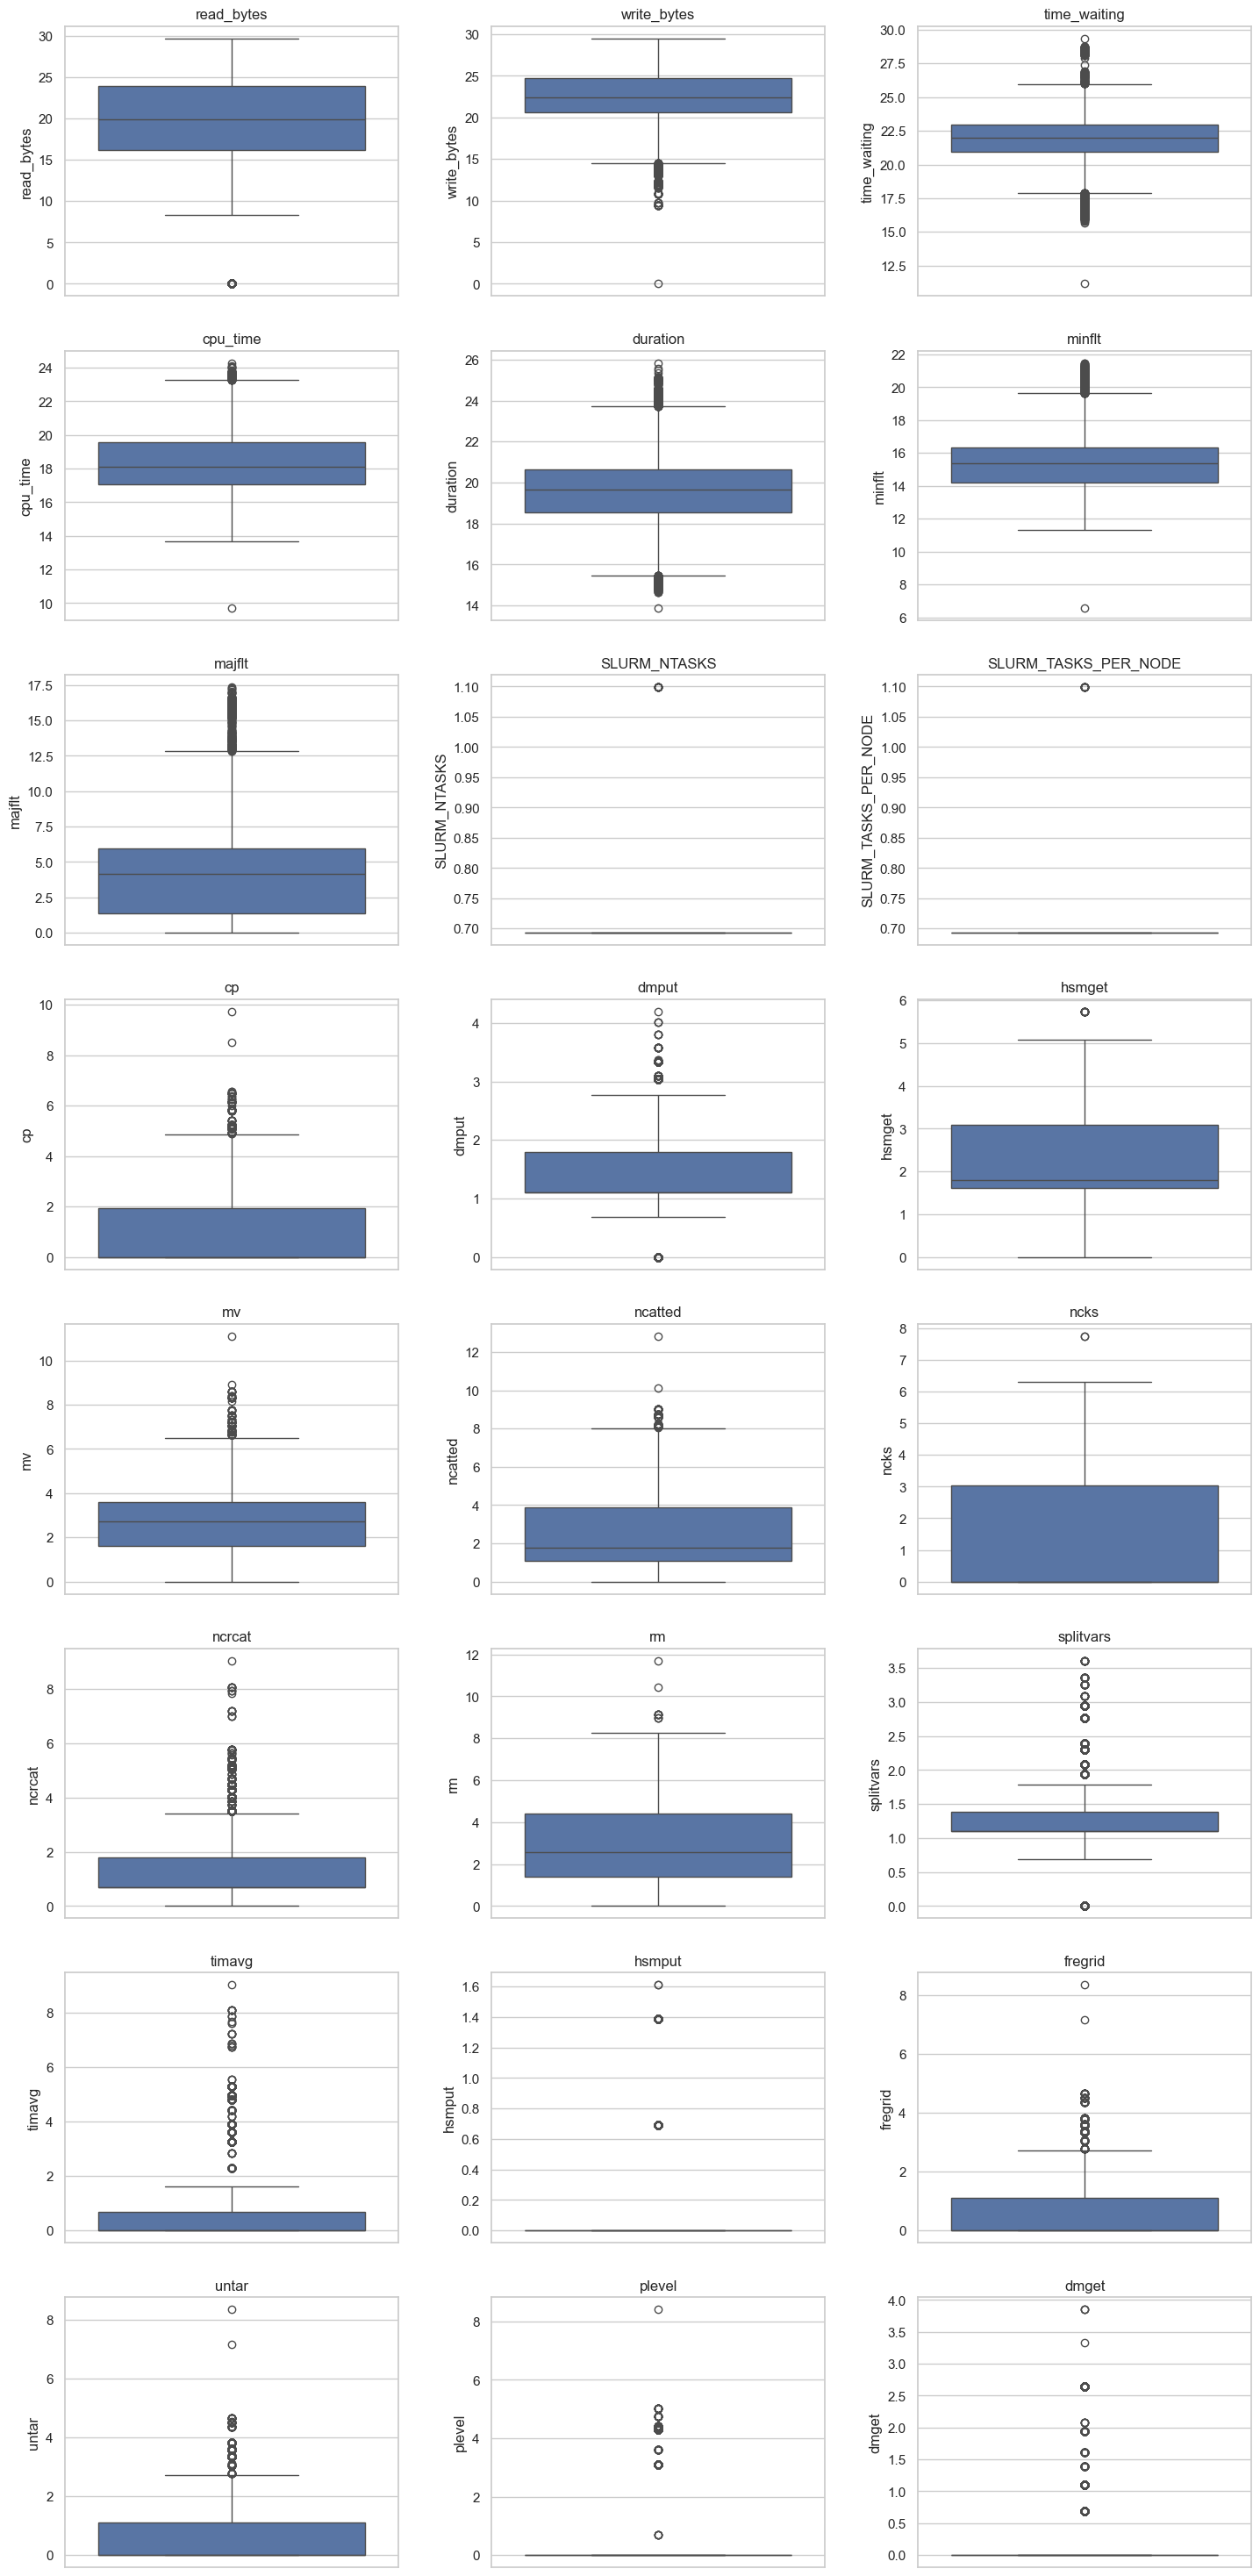

In [34]:
fig, axes = plt.subplots(8, 3, figsize=(15,30))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_log_trans[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout(pad=2.5)

#### Article on outlier detection: https://www.geeksforgeeks.org/data-analysis/detect-and-remove-the-outliers-using-python/

- Trying to remove rows that are too outside of the box and whiskers.

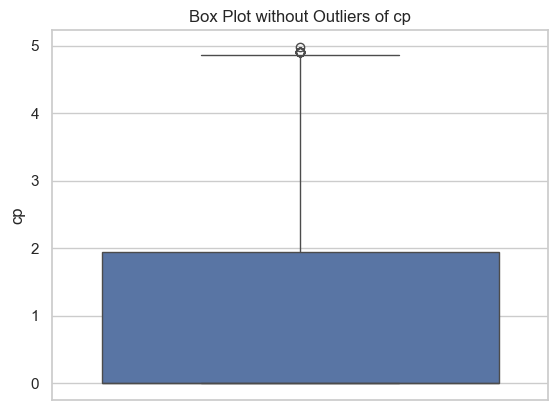

count    40000.000000
mean         1.111400
std          1.356118
min          0.000000
25%          0.000000
50%          0.000000
75%          1.945910
max          9.720466
Name: cp, dtype: float64

In [35]:
# Outlier detection on 'cp'
def removal_box_plot(df, column, threshold):
    removed_outliers = df[df[column] <= threshold]

    sns.boxplot(removed_outliers[column])
    plt.title(f'Box Plot without Outliers of {column}')
    plt.show()
    return removed_outliers

no_outliers = removal_box_plot(df_log_trans, 'cp', 5)
df_log_trans['cp'].describe()

In [36]:
df_log_trans.corr(numeric_only=True)['cpu_time'].sort_values(ascending=False)

cpu_time                1.000000
duration                0.893371
minflt                  0.858339
write_bytes             0.824962
time_waiting            0.766093
read_bytes              0.727871
majflt                  0.559370
mv                      0.488728
rm                      0.470521
ncatted                 0.469792
cp                      0.442007
fregrid                 0.399948
untar                   0.397318
ncrcat                  0.382431
dmput                   0.363163
timavg                  0.343097
ncks                    0.333466
splitvars               0.303965
hsmput                  0.260908
hsmget                  0.244927
plevel                  0.144684
dmget                   0.120708
SLURM_TASKS_PER_NODE   -0.017980
SLURM_NTASKS           -0.017983
Name: cpu_time, dtype: float64

If I'm still trying to predict cpu_time, then it looks okay to me to remove the highest skewed columns that are the least correlated to the cpu_time.

In [37]:
df_clean = df_log_trans.drop(columns=['hsmput','plevel','dmget','SLURM_TASKS_PER_NODE','SLURM_NTASKS'])
df_clean.corr(numeric_only=True)['cpu_time'].sort_values(ascending=False)

cpu_time        1.000000
duration        0.893371
minflt          0.858339
write_bytes     0.824962
time_waiting    0.766093
read_bytes      0.727871
majflt          0.559370
mv              0.488728
rm              0.470521
ncatted         0.469792
cp              0.442007
fregrid         0.399948
untar           0.397318
ncrcat          0.382431
dmput           0.363163
timavg          0.343097
ncks            0.333466
splitvars       0.303965
hsmget          0.244927
Name: cpu_time, dtype: float64

In [38]:
df_clean.head()

,read_bytes,write_bytes,time_waiting,cpu_time,duration,start,end,minflt,majflt,tags,...,hsmget,mv,ncatted,ncks,ncrcat,rm,splitvars,timavg,fregrid,untar
0,25.686867,25.196333,21.178675,19.315824,21.024541,2026-01-28 09:15:39.211909,2026-01-28 09:38:10.792654,16.595646,4.499810,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,1.791759,2.708050,1.791759,1.098612,1.386294,2.564949,1.098612,0.693147,0.0,0.0
1,26.997183,26.491772,21.198902,20.519708,21.712899,2026-01-28 09:15:39.224952,2026-01-28 10:00:29.471986,18.024777,4.564348,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,1.791759,2.708050,1.791759,1.098612,1.386294,2.564949,1.098612,0.693147,0.0,0.0
2,23.754981,23.460674,20.976034,18.079300,20.821709,2026-01-28 09:15:39.234004,2026-01-28 09:34:02.685979,15.533278,0.693147,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,1.791759,3.401197,2.197225,4.532599,2.302585,3.555348,1.098612,1.609438,0.0,0.0
3,14.739389,16.031551,20.782174,16.571821,20.468218,2026-01-28 09:15:39.267702,2026-01-28 09:28:34.147049,14.420871,2.302585,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,3.218876,2.708050,1.791759,1.098612,1.386294,2.564949,1.098612,0.693147,0.0,0.0
4,24.662084,24.407498,21.604099,19.514315,21.228419,2026-01-28 09:15:39.495806,2026-01-28 09:43:16.734767,16.135398,0.000000,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,1.791759,3.401197,2.197225,4.532599,2.302585,3.555348,1.098612,1.609438,0.0,0.0


### IQR - Trying to address outliers
* Compute Q1 (25th percentile), Q3 (75th percentile), IQR (Q3-Q1)
* Pick some outlier thresholds, suggested
  * lower: Q1-1.5*IQR
  * upper: Q3-1.5*IQR
* Flag outliers
* Potentially remove/clip outliers?

In [39]:
numeric_cols = df_clean.select_dtypes(include="number").columns.tolist()
numeric_cols
q1 = df_clean[numeric_cols].quantile(0.25)
q3 = df_clean[numeric_cols].quantile(0.75)
iqr = q3-q1
iqr

read_bytes      7.750636
write_bytes     4.108889
time_waiting    2.029367
cpu_time        2.487559
duration        2.059099
minflt          2.174116
majflt          4.580493
cp              1.945910
dmput           0.693147
hsmget          1.481605
mv              1.974081
ncatted         2.772589
ncks            3.044522
ncrcat          1.098612
rm              3.032546
splitvars       0.287682
timavg          0.693147
fregrid         1.098612
untar           1.098612
dtype: float64

In [40]:
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
lower, upper

(read_bytes       4.550452
 write_bytes     14.452213
 time_waiting    17.873178
 cpu_time        13.340682
 duration        15.476442
 minflt          10.927547
 majflt          -5.484445
 cp              -2.918865
 dmput            0.058892
 hsmget          -0.612969
 mv              -1.351684
 ncatted         -3.060271
 ncks            -4.566784
 ncrcat          -0.954771
 rm              -3.162525
 splitvars        0.667089
 timavg          -1.039721
 fregrid         -1.647918
 untar           -1.647918
 dtype: float64,
 read_bytes      35.552998
 write_bytes     30.887767
 time_waiting    25.990648
 cpu_time        23.290917
 duration        23.712838
 minflt          19.624009
 majflt          12.837526
 cp               4.864775
 dmput            2.831480
 hsmget           5.313449
 mv               6.544640
 ncatted          8.030084
 ncks             7.611306
 ncrcat           3.439678
 rm               8.967660
 splitvars        1.817817
 timavg           1.732868
 fregrid   

In [41]:
outliers = (df_clean[numeric_cols] < lower) | (df_clean[numeric_cols] > upper)
outliers.sum()

read_bytes        850
write_bytes       795
time_waiting      753
cpu_time          208
duration          824
minflt            461
majflt            281
cp                260
dmput            8285
hsmget             15
mv                166
ncatted           134
ncks                2
ncrcat           4388
rm                 12
splitvars       11355
timavg           4653
fregrid          1539
untar            1539
dtype: int64

In [42]:
outliers.sum(axis=1)

0        0
1        0
2        0
3        0
4        0
        ..
39995    0
39996    2
39997    1
39998    2
39999    2
Length: 40000, dtype: int64

In [43]:
# Try clipping data out of the upper/lower bounds... basically restricting the outliers a bit?

df_within_bounds = df_clean.copy()
df_within_bounds[numeric_cols] = df_within_bounds[numeric_cols].clip(lower=lower, upper=upper, axis=1)
df_within_bounds.describe()

,read_bytes,write_bytes,time_waiting,cpu_time,duration,minflt,majflt,cp,dmput,hsmget,mv,ncatted,ncks,ncrcat,rm,splitvars,timavg,fregrid,untar
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,19.639722,22.116485,21.980490,18.345335,19.639494,15.372184,3.894652,1.107513,1.211344,2.006829,2.436153,2.354246,1.221747,1.248145,2.626991,1.179136,0.463213,0.577836,0.580086
std,4.908216,3.511483,1.514263,1.864980,1.633205,1.657578,2.727846,1.343676,0.714809,1.145434,1.628920,1.853042,1.933404,1.005485,1.902705,0.336509,0.643182,0.839942,0.839879
min,4.550452,14.452213,17.873178,13.340682,15.476442,10.927547,0.000000,0.000000,0.058892,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.667089,0.000000,0.000000,0.000000
25%,16.176407,20.615546,20.917229,17.072020,18.565090,14.188720,1.386294,0.000000,1.098612,1.609438,1.609438,1.098612,0.000000,0.693147,1.386294,1.098612,0.000000,0.000000,0.000000
50%,19.852722,22.415513,22.004250,18.105225,19.670361,15.351910,4.158883,0.000000,1.098612,1.791759,2.708050,1.791759,0.000000,0.693147,2.564949,1.098612,0.000000,0.000000,0.000000
75%,23.927043,24.724435,22.946597,19.559579,20.624190,16.362836,5.966787,1.945910,1.791759,3.091042,3.583519,3.871201,3.044522,1.791759,4.418841,1.386294,0.693147,1.098612,1.098612
max,29.686951,29.497051,25.990648,23.290917,23.712838,19.624009,12.837526,4.864775,2.831480,5.313449,6.544640,8.030084,7.611306,3.439678,8.967660,1.817817,1.732868,2.746531,2.746531


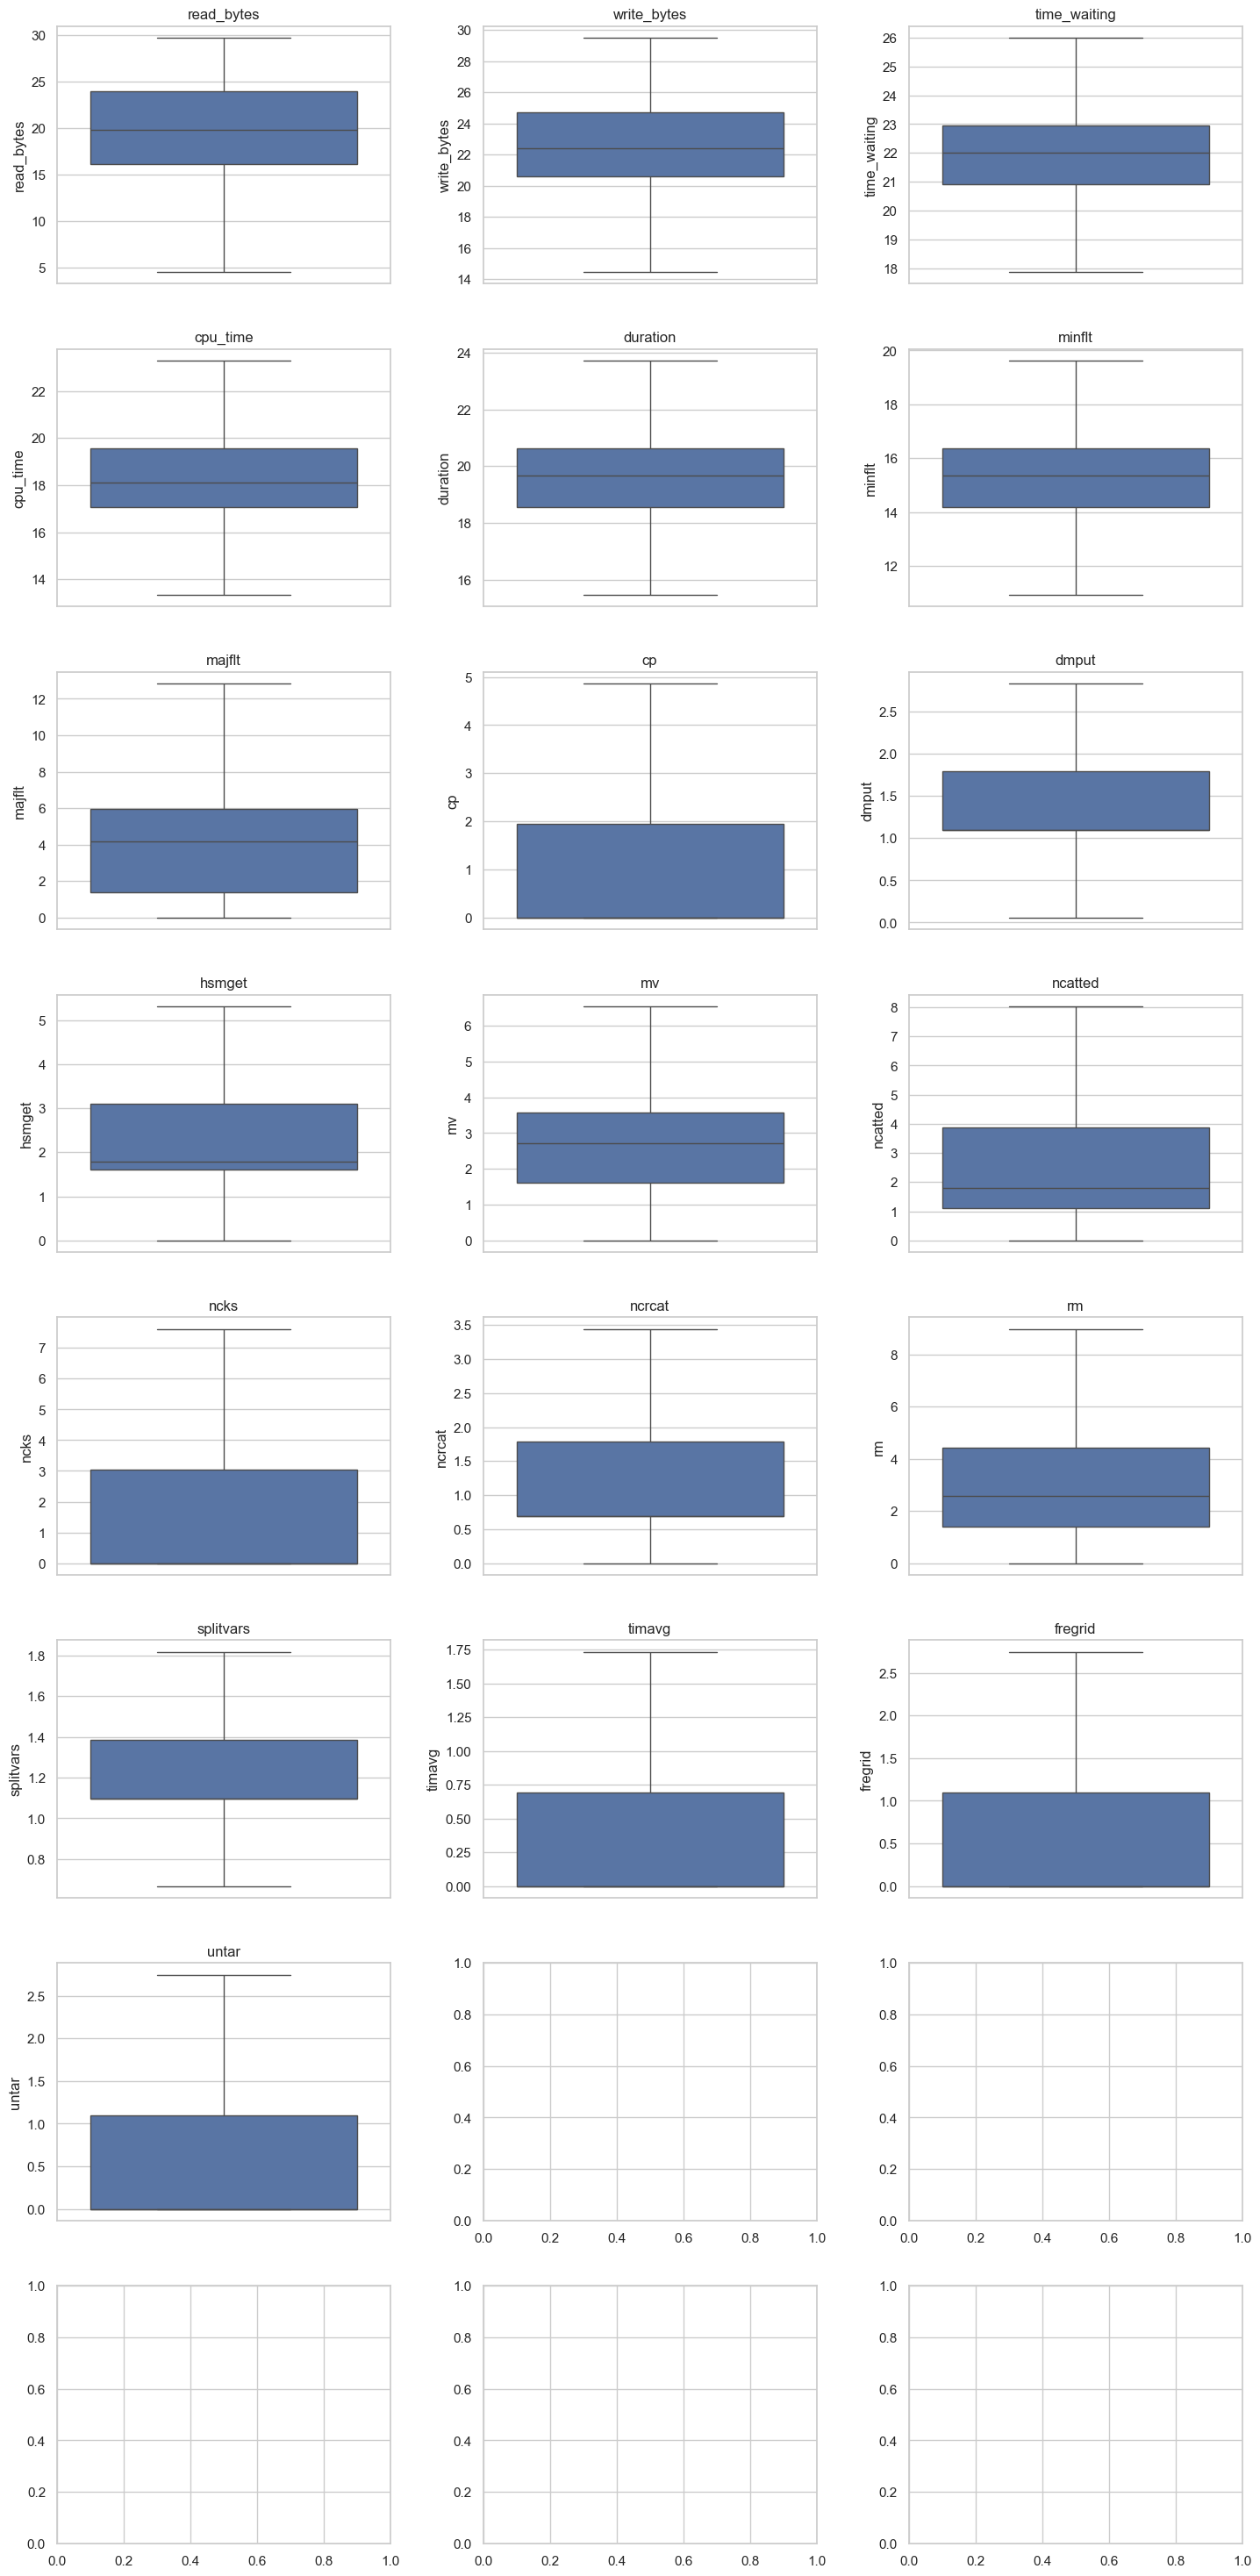

In [44]:
fig, axes = plt.subplots(8, 3, figsize=(15,30))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_within_bounds[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout(pad=2.5)

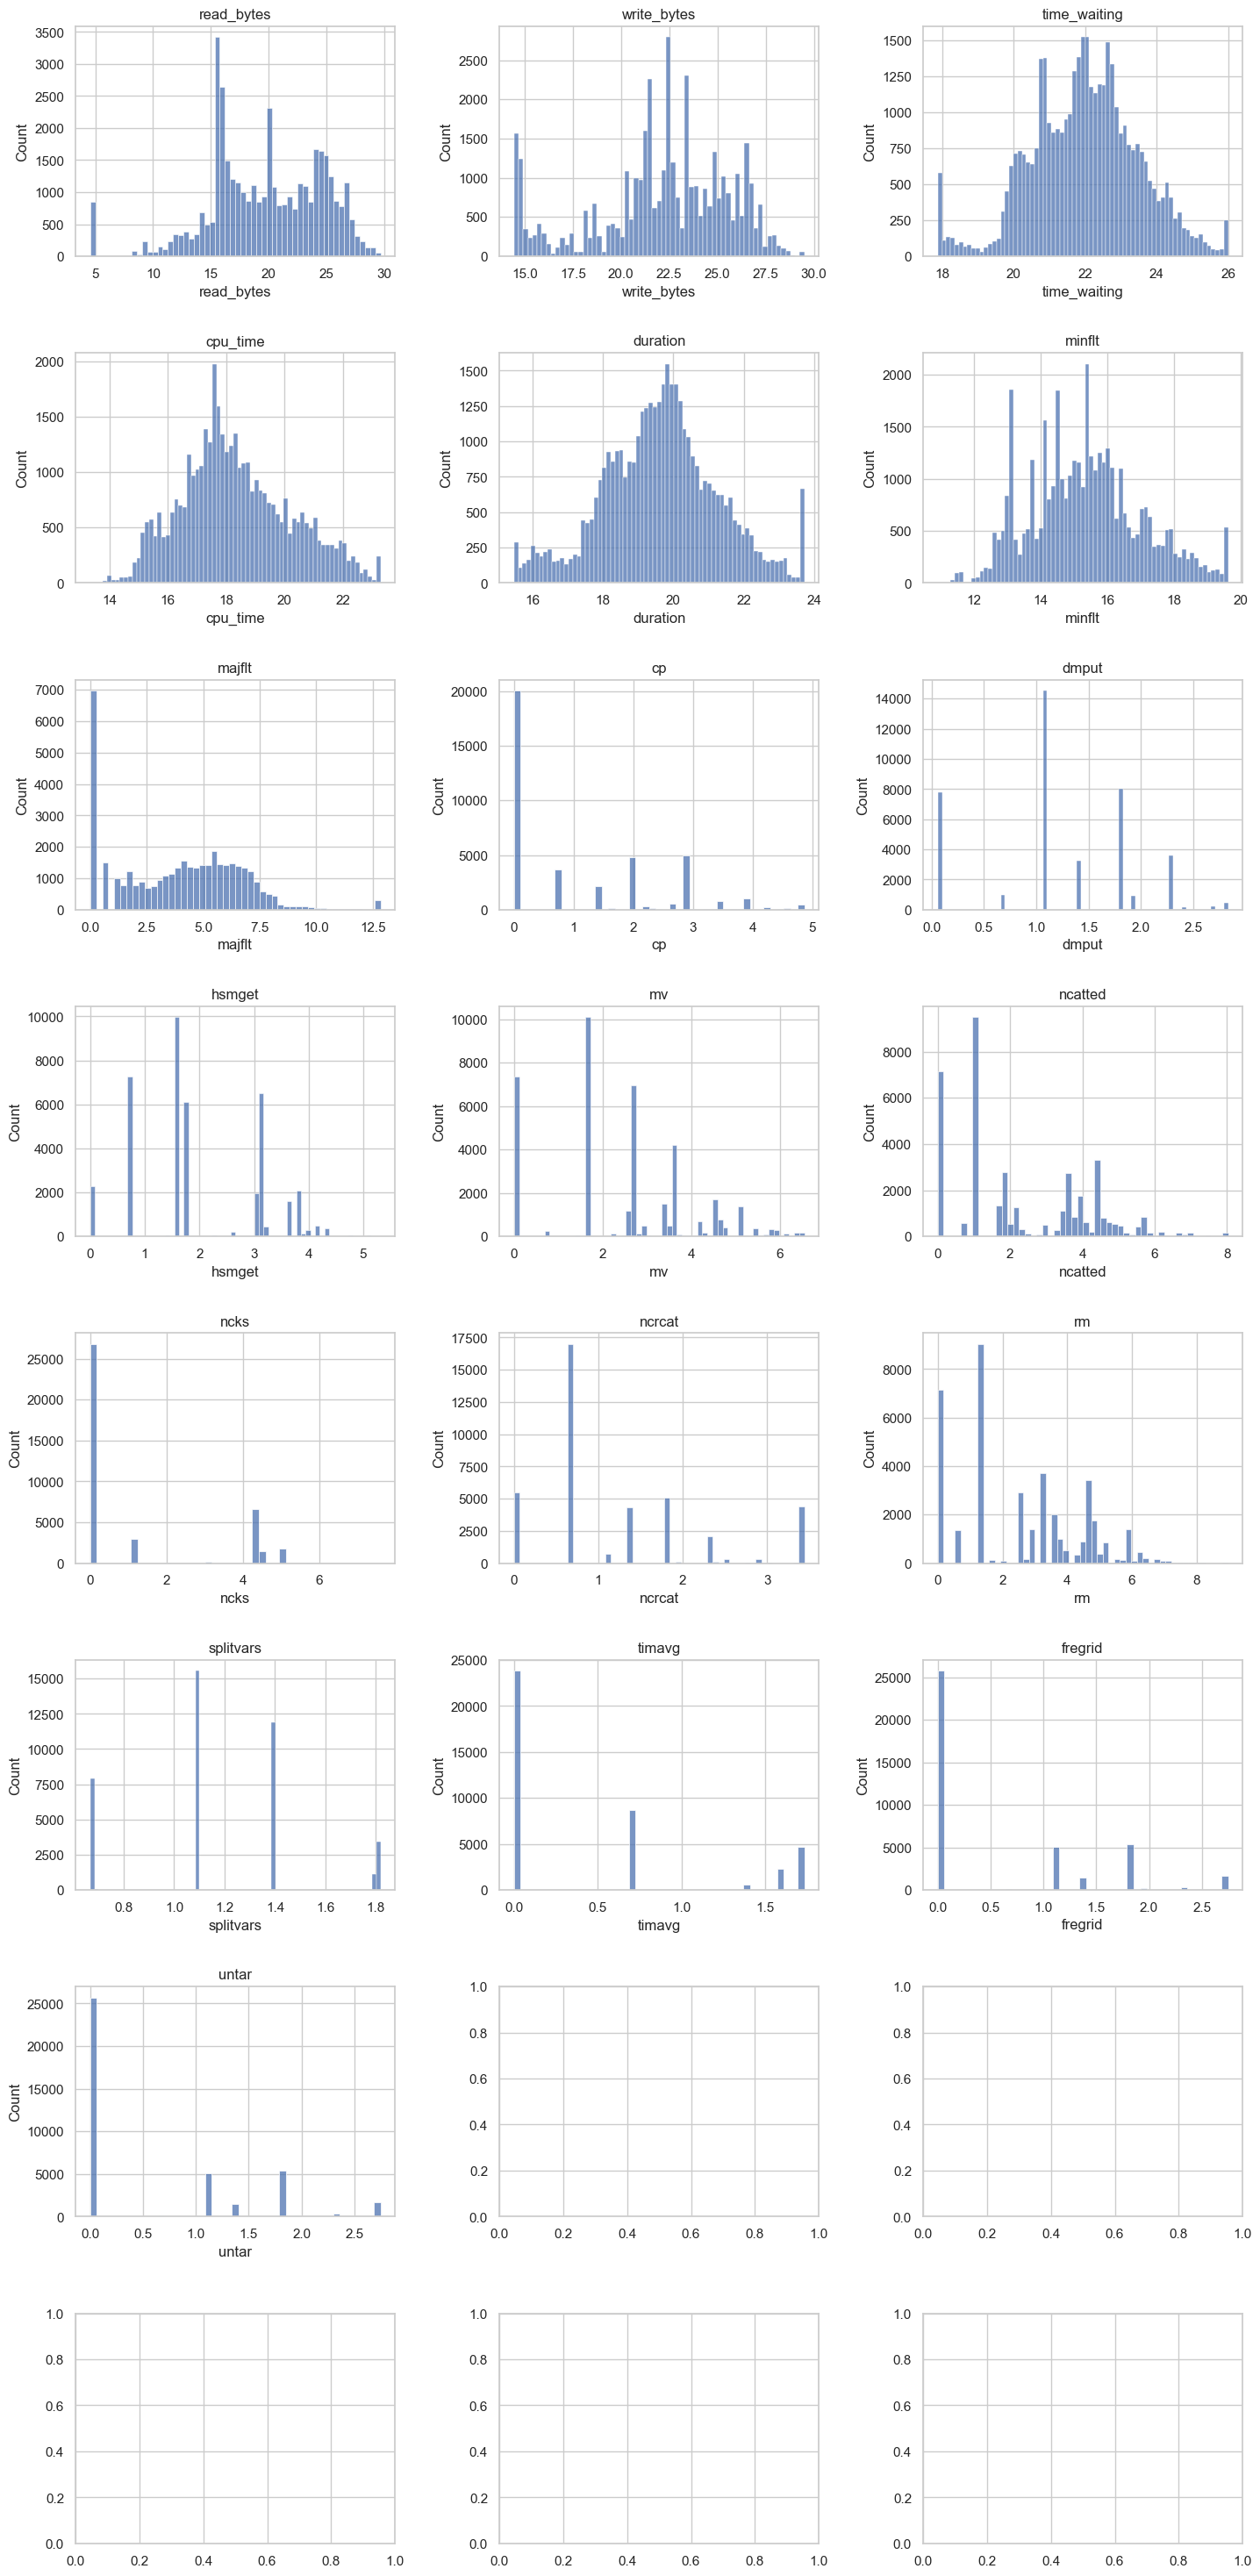

In [45]:
fig, axes = plt.subplots(8, 3, figsize=(15,30))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df_within_bounds[col], ax=axes[i])
    #sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout(pad=2.5)

In [46]:
df_clean=df_within_bounds

# One-hot Encoding the Non-numerical Data

In [47]:
from sklearn.preprocessing import OneHotEncoder

category_cols

['start',
 'end',
 'tags',
 'annotations',
 'all_proc_tags',
 'SLURM_JOB_ACCOUNT',
 'SLURM_SCRIPT_CONTEXT',
 'LOADEDMODULES',
 'EPMT_JOB_TAGS',
 'papiex-error',
 'papiex-error-process-ids',
 'parsed_EPMT_JOB_TAGS',
 'exp_component',
 'exp_fre_mod',
 'exp_name',
 'exp_time',
 'exp_platform',
 'exp_target',
 'exp_seg_months',
 'script_name']

In [48]:
df_clean[category_cols].head()

,start,end,tags,annotations,all_proc_tags,SLURM_JOB_ACCOUNT,SLURM_SCRIPT_CONTEXT,LOADEDMODULES,EPMT_JOB_TAGS,papiex-error,papiex-error-process-ids,parsed_EPMT_JOB_TAGS,exp_component,exp_fre_mod,exp_name,exp_time,exp_platform,exp_target,exp_seg_months,script_name
0,2026-01-28 09:15:39.211909,2026-01-28 09:38:10.792654,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,{'EPMT_JOB_TAGS': 'exp_component:ocean_rho2;ex...,"[{'op': 'cp', 'op_instance': '1'}, {'op': 'dmp...",gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ocean_rho2;exp_fre_mod:/home/fms...,NaN,NaN,"{'exp_component': 'ocean_rho2', 'exp_fre_mod':...",ocean_rho2,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
1,2026-01-28 09:15:39.224952,2026-01-28 10:00:29.471986,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,{'EPMT_JOB_TAGS': 'exp_component:ocean_z;exp_f...,"[{'op': 'cp', 'op_instance': '1'}, {'op': 'dmp...",gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ocean_z;exp_fre_mod:/home/fms/lo...,NaN,NaN,"{'exp_component': 'ocean_z', 'exp_fre_mod': '/...",ocean_z,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
2,2026-01-28 09:15:39.234004,2026-01-28 09:34:02.685979,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,{'EPMT_JOB_TAGS': 'exp_component:ocean;exp_fre...,"[{'op': 'cp', 'op_instance': '1'}, {'op': 'dmp...",gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ocean;exp_fre_mod:/home/fms/loca...,NaN,NaN,"{'exp_component': 'ocean', 'exp_fre_mod': '/ho...",ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
3,2026-01-28 09:15:39.267702,2026-01-28 09:28:34.147049,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,{'EPMT_JOB_TAGS': 'exp_component:ocean_scalar;...,"[{'op': 'cp', 'op_instance': '1'}, {'op': 'dmp...",gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ocean_scalar;exp_fre_mod:/home/f...,NaN,NaN,"{'exp_component': 'ocean_scalar', 'exp_fre_mod...",ocean_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
4,2026-01-28 09:15:39.495806,2026-01-28 09:43:16.734767,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,{'EPMT_JOB_TAGS': 'exp_component:ice;exp_fre_m...,"[{'op': 'cp', 'op_instance': '1'}, {'op': 'dmp...",gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ice;exp_fre_mod:/home/fms/local/...,NaN,NaN,"{'exp_component': 'ice', 'exp_fre_mod': '/home...",ice,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...


### Removing some columns
There's a bit of clean up here. Some of the columns were expanded out already. Some of the values (like the papiex columns) seems to have a lot of NaN values. So, I'll drop some of these here.

In [49]:
df_clean.drop(columns=['annotations', 'all_proc_tags', 'papiex-error', 'papiex-error-process-ids', 'parsed_EPMT_JOB_TAGS'], inplace=True)

In [50]:
category_cols = df_clean.select_dtypes(exclude="number").columns.tolist()
df_clean[category_cols].head()

,start,end,tags,SLURM_JOB_ACCOUNT,SLURM_SCRIPT_CONTEXT,LOADEDMODULES,EPMT_JOB_TAGS,exp_component,exp_fre_mod,exp_name,exp_time,exp_platform,exp_target,exp_seg_months,script_name
0,2026-01-28 09:15:39.211909,2026-01-28 09:38:10.792654,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ocean_rho2;exp_fre_mod:/home/fms...,ocean_rho2,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
1,2026-01-28 09:15:39.224952,2026-01-28 10:00:29.471986,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ocean_z;exp_fre_mod:/home/fms/lo...,ocean_z,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
2,2026-01-28 09:15:39.234004,2026-01-28 09:34:02.685979,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ocean;exp_fre_mod:/home/fms/loca...,ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
3,2026-01-28 09:15:39.267702,2026-01-28 09:28:34.147049,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ocean_scalar;exp_fre_mod:/home/f...,ocean_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
4,2026-01-28 09:15:39.495806,2026-01-28 09:43:16.734767,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ice;exp_fre_mod:/home/fms/local/...,ice,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
